[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BartekDaniluk/Big_Data/blob/main/ML%20cz.3%20-%20Uczenie%20nienadzorowane.ipynb)

# ML cz.3 — Uczenie Nienadzorowane

W poprzednich notebookach omówiliśmy dwa podstawowe typy uczenia maszynowego:

* **Regresja** — przewidywanie ciągłej wartości liczbowej (np. cena mieszkania)
* **Klasyfikacja** — przewidywanie do której kategorii należy dany obiekt (np. spam / nie-spam)

Oba te zadania należą do paradygmatu **uczenia nadzorowanego** (Supervised Learning). Mamy etykiety, wiemy "co jest co", a model uczy się mapowania *wejście → odpowiedź*.

Teraz przechodzimy do zupełnie innego świata: **uczenia nienadzorowanego** (Unsupervised Learning).

## Na czym polega różnica?

Wyobraź sobie że dostajesz pudełko 10 000 zdjęć kotów, psów i papug — ale bez żadnych podpisów. Algorytm nadzorowany po prostu nie ma co robić, bo nie ma żadnych "prawdziwych odpowiedzi" do których mógłby porównywać swoje wyniki.

Algorytm **nienadzorowany** jednak patrzy na surowe dane i pyta: *"Hej, czy gdzieś w tych danych ukryte są jakieś naturalne grupy / wzorce / zależności?"*. I najczęściej — są.

| Cecha | Uczenie nadzorowane | Uczenie nienadzorowane |
|---|---|---|
| **Dane wejściowe** | Opatrzone etykietami (np. `[zdjęcie, "pies"]`) | Surowe, bez etykiet |
| **Cel** | Naucz się przewidywać odpowiedź | Znajdź ukrytą strukturę |
| **Sygnał uczący** | Błąd vs. prawdziwa etykieta | Brak zewnętrznego sygnału — tylko geometria danych |
| **Przykłady** | Klasyfikacja spamu, predykcja cen | Segmentacja klientów, kompresja cech, wykrywanie anomalii |
| **Ewaluacja** | Accuracy, F1, RMSE | Silhouette Score, Davies-Bouldin, Explained Variance |

## Dlaczego to ważne w prawdziwym świecie?

W akademii i na kursach uczenie nadzorowane dominuje — bo jest intuicyjne i łatwe do oceny.
W przemyśle to uczenie **nienadzorowane jest często ważniejsze**, z prostej przyczyny:

> **Zdecydowana większość danych w świecie rzeczywistym nie ma etykiet.**

Każdy packet sieciowy, każde odczytanie czujnika IoT, każde kliknięcie użytkownika — to surowe dane. Ręczne etykietowanie jest absurdalnie drogie i powolne. Zanim więc w ogóle możemy myśleć o uczeniu nadzorowanym, ktoś musi te dane *zrozumieć* — i właśnie do tego służy uczenie nienadzorowane.

> **Wskazówka Big Data:** W środowiskach produkcyjnych (np. cybersecurity, fintech, genomika, e-commerce) algorytmy nienadzorowane działają 24/7 na strumieniach danych w czasie rzeczywistym. Wykrywają anomalie w transakcjach (fraud detection), segmentują miliony użytkowników bez ich ręcznego opisywania, czy kompresują petabajty logów do postaci nadającej się do analizy. W ekosystemach jak Apache Spark czy RAPIDS cuML (NVIDIA) te same algorytmy działają na klastrach GPU / wielu maszynach jednocześnie, skalując się do terabajtów danych.

## Trzy filary uczenia nienadzorowanego

W tym notebooku omówimy trzy główne kategorie:

1. **Redukcja wymiarowości** (Dimensionality Reduction) — "spłaszczamy" dane z wielu wymiarów do 2–3, żeby je zobaczyć i lepiej zrozumieć
2. **Klasteryzacja** (Clustering) — grupujemy dane w naturalne skupiska bez wcześniejszej wiedzy o tym, ile ich jest
3. **Reguły asocjacyjne** (Association Rules) — szukamy, które rzeczy "chodzą razem" (klasyczny przykład: analiza koszyka zakupowego)
"""

In [60]:
!pip install umap-learn mlxtend -q

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Datasets
from sklearn.datasets import load_digits, make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Hierarchical dendrogram (scipy)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Clustering evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Association rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Część 1: Redukcja Wymiarowości

## Przekleństwo Wymiarowości (Curse of Dimensionality)

Zanim przejdziemy do algorytmów, musimy zrozumieć *problem*, który rozwiązują.

Wyobraź sobie, że masz dane o klientach sklepu: wiek, dochód, liczba zakupów — to 3 wymiary. Można je narysować w 3D. Easy.

Teraz wyobraź sobie, że masz 500 cech na każdego klienta. Nie da się tego narysować. Co gorsza — w przestrzeni 500-wymiarowej wszystkie punkty są od siebie "tak samo daleko". Algorytmy oparte na odległości (jak K-Means czy KNN) zaczynają zawodzić. Modele overfittują.

To właśnie Przekleństwo Wymiarowości. Rozwiązanie? Zmniejszyć liczbę wymiarów, zachowując jak najwięcej istotnej informacji.

Będziemy pracować na klasycznym zbiorze **Digits** — 1797 odręcznie napisanych cyfr (0–9), każda reprezentowana jako obraz 8×8 pikseli, co daje **64 cechy** na próbkę.

Kształt danych: (1797, 64)
Liczba klas: 10
Przykładowa próbka (pierwsze 10 pikseli): [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0.]


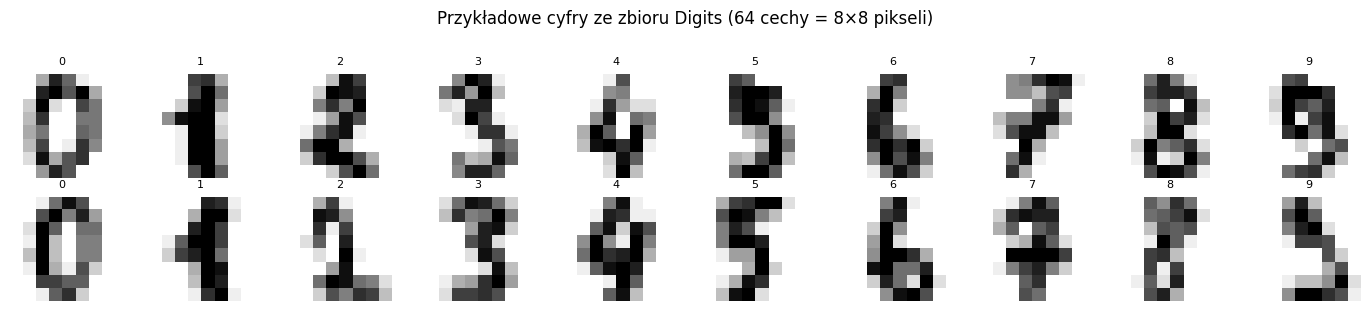

In [62]:
digits = load_digits()
X, y = digits.data, digits.target

print(f"Kształt danych: {X.shape}")     # (1797, 64)
print(f"Liczba klas: {len(np.unique(y))}")
print(f"Przykładowa próbka (pierwsze 10 pikseli): {X[0, :10]}")

# Zobaczmy jak wyglądają przykładowe cyfry
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(str(digits.target[i]), fontsize=8)
    ax.axis('off')
plt.suptitle('Przykładowe cyfry ze zbioru Digits (64 cechy = 8×8 pikseli)', y=1.02)
plt.tight_layout()
plt.show()

In [63]:
# Standaryzacja jest KLUCZOWA przed większością algorytmów unsupervised learning.
# Cechy z różnymi skalami (np. wiek 0-100 vs. dochód 0-100000) psują metryki odległości.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Średnia przed standaryzacją: {X.mean():.2f}, po: {X_scaled.mean():.4f}")
print(f"Odch. std. przed: {X.std():.2f}, po: {X_scaled.std():.4f}")

Średnia przed standaryzacją: 4.88, po: 0.0000
Odch. std. przed: 6.02, po: 0.9763


## PCA — Principal Component Analysis (Analiza Głównych Składowych)

PCA to klasyczny, liniowy i deterministyczny algorytm redukcji wymiarowości.

**Intuicja:** Wyobraź sobie że masz chmurę punktów w 3D, która wygląda jak spłaszczony naleśnik. Większość "informacji" (wariancji) leży w płaszczyźnie naleśnika. PCA po prostu znajduje tę płaszczyznę i rzutuje na nią dane.

Technicznie PCA oblicza **macierz kowariancji** danych i wyznacza jej **wektory własne** (eigenvectors). Te wektory to nowe osie (tzw. *principal components*), ułożone tak, że:
- **PC1** — kierunek maksymalnej wariancji
- **PC2** — kierunek maksymalnej wariancji, prostopadły do PC1
- **PC3** — i tak dalej...

Każdy komponent jest prostopadły do pozostałych (ortogonalny). Pierwszy komponent "wyjaśnia" najwięcej wariancji, drugi — najwięcej z reszty, itd.

**Kluczowe zalety PCA:**
- Deterministyczny — zawsze daje ten sam wynik
- Szybki i skalowalny
- Interpretowalny — wiemy ile % wariancji każdy komponent "trzyma"

**Kluczowe wady:**
- Tylko liniowy — nie wykrywa krzywoliniowych zależności
- Komponenty są nowe osie, nie oryginalne cechy — trudniejsze do interpretacji domenowej

In [64]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Wymiar przed PCA: {X_scaled.shape}")
print(f"Wymiar po PCA:    {X_pca.shape}")
print(f"\nWariancja wyjaśniona przez PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"Wariancja wyjaśniona przez PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")
print(f"Łącznie (2 komponenty):         {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

Wymiar przed PCA: (1797, 64)
Wymiar po PCA:    (1797, 2)

Wariancja wyjaśniona przez PC1: 12.0%
Wariancja wyjaśniona przez PC2: 9.6%
Łącznie (2 komponenty):         21.6%


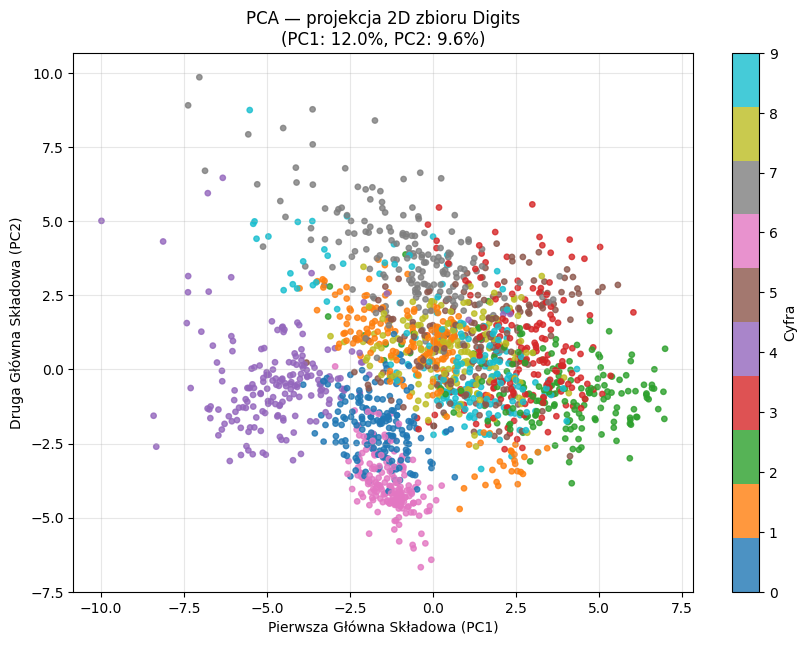

In [65]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=15, alpha=0.8)
plt.colorbar(scatter, label='Cyfra')
plt.title(f'PCA — projekcja 2D zbioru Digits\n(PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%, PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.xlabel('Pierwsza Główna Składowa (PC1)')
plt.ylabel('Druga Główna Składowa (PC2)')
plt.grid(True, alpha=0.3)
plt.show()

Widać że PCA jako-tako oddziela cyfry, ale wiele grup się zachodzi. Cyferki 0 i 6 są trochę pomieszane z innymi, a liczby jak 1 i 7 chodzą blisko siebie. To dlatego że PCA szuka tylko **liniowych** zależności.

## Scree Plot — Ile komponentów wybrać?

Gdy robimy PCA nie zawsze chcemy tylko 2 komponenty (do wizualizacji). Często chcemy zredukować wymiarowość do np. 10–30 komponentów przed wrzuceniem danych do innego modelu. Wtedy przydaje się **Scree Plot** — wykres pokazujący ile skumulowanej wariancji wyjaśniamy kolejnymi komponentami.


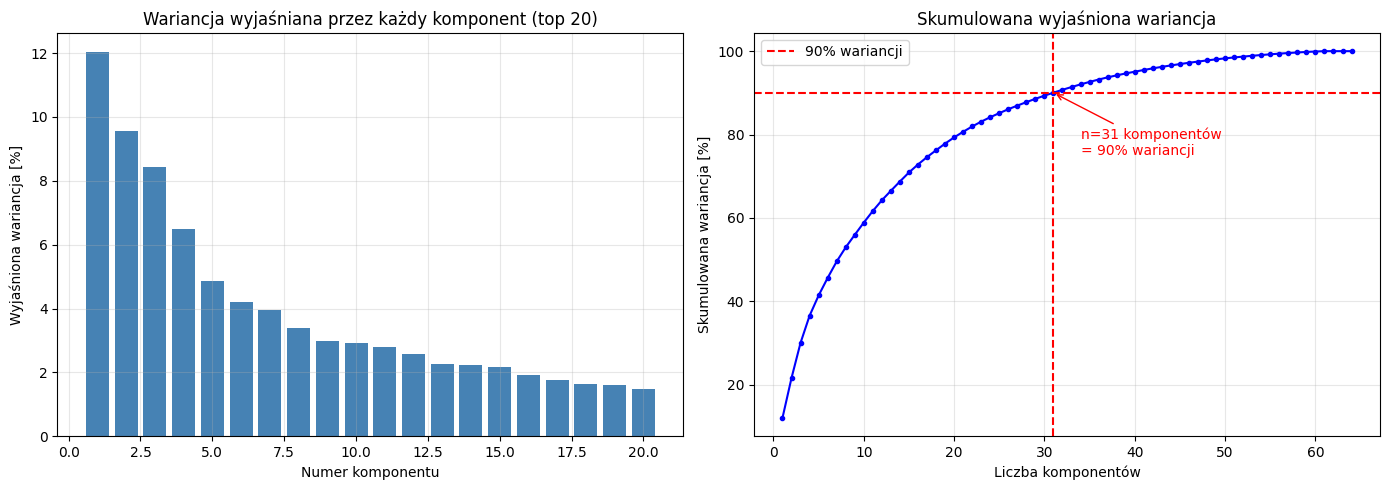

Aby zachować 90% wariancji, wystarczy 31 komponentów zamiast 64 — redukcja 33 cech!


In [66]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: wariancja per komponent
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100, color='steelblue')
axes[0].set_title('Wariancja wyjaśniana przez każdy komponent (top 20)')
axes[0].set_xlabel('Numer komponentu')
axes[0].set_ylabel('Wyjaśniona wariancja [%]')
axes[0].grid(True, alpha=0.3)

# Wykres 2: skumulowana wariancja
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 'b-o', markersize=3)
axes[1].axhline(y=90, color='r', linestyle='--', label='90% wariancji')
axes[1].axvline(x=n_components_90, color='r', linestyle='--')
axes[1].annotate(f'n={n_components_90} komponentów\n= 90% wariancji',
                 xy=(n_components_90, 90), xytext=(n_components_90 + 3, 75),
                 arrowprops=dict(arrowstyle='->', color='red'), color='red')
axes[1].set_title('Skumulowana wyjaśniona wariancja')
axes[1].set_xlabel('Liczba komponentów')
axes[1].set_ylabel('Skumulowana wariancja [%]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Aby zachować 90% wariancji, wystarczy {n_components_90} komponentów zamiast 64 — redukcja {64 - n_components_90} cech!")

## t-SNE — t-Distributed Stochastic Neighbor Embedding

PCA świetnie radzi sobie z danymi liniowymi. Ale prawdziwe dane (obrazy, tekst, sekwencje DNA) mają **nieliniową** strukturę. Tu wchodzi t-SNE.

**Intuicja:** t-SNE patrzy na każdy punkt i pyta: *"które punkty są moimi najbliższymi sąsiadami w oryginalnej wysokowymiarowej przestrzeni?"* Następnie stara się ułożyć wszystkie punkty w 2D tak, żeby sąsiedzi nadal byli blisko siebie.

Matematycznie: t-SNE modeluje podobieństwa parami za pomocą **rozkładu Gaussowskiego** w wysokowymiarowej przestrzeni, a w niskowym 2D używa **rozkładu t-Studenta** (stąd "t" w nazwie). Rozkład t ma "grubsze ogony" — to pomaga rozciągnąć klastry na zewnątrz i nie ścisnąć wszystkiego w centrum.

**Kluczowy parametr: `perplexity`**
Kontroluje ile "sąsiadów" bierze pod uwagę każdy punkt. Typowe wartości: 5–50. Za małe → rozpadnie się na izolowane wyspy. Za duże → klastry się zleją.

⚠️ **Ważne ostrzeżenia dot. t-SNE:**
- Jest **stochastyczny** — każdy run daje inne wyniki (`random_state` żeby utrwalić)
- **Odległości między klastrami są bez znaczenia** — tylko lokalne struktury wewnątrz klastrów są wiarygodne
- **Wolny** na dużych danych — nie nadaje się do produkcji na milionach rekordów

> **Wskazówka Big Data:** W praktyce t-SNE używa się głównie do **eksploracji i wizualizacji** — żeby zobaczyć czy w danych są w ogóle jakieś naturalne grupy. Nie używa się go jako preprocessing przed modelowaniem. Do tego lepiej PCA lub UMAP.
"""

Uruchamiam t-SNE... (może chwilę potrwać)


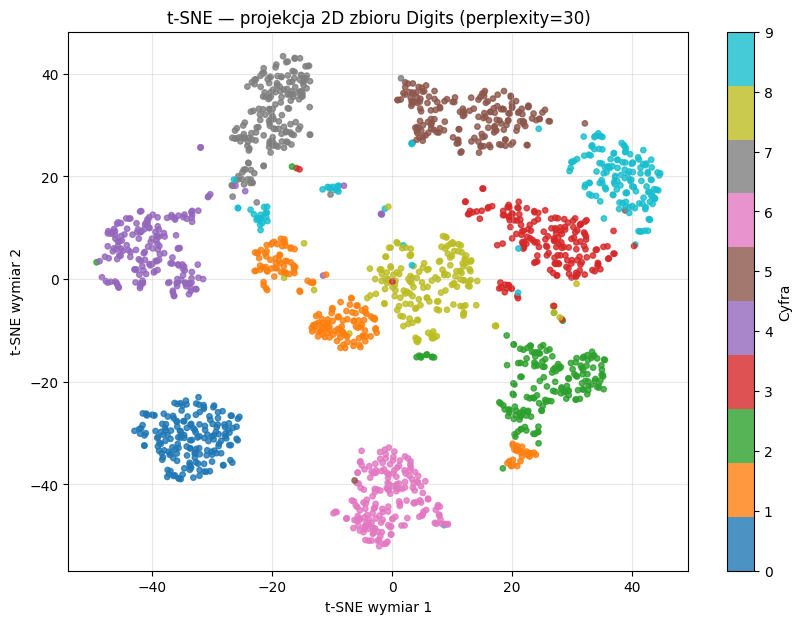

In [67]:
print("Uruchamiam t-SNE... (może chwilę potrwać)")

tsne = TSNE(
    n_components=2,
    perplexity=30,      # ile sąsiadów bierze pod uwagę — typowo 5-50
    random_state=42,    # KONIECZNE żeby wynik był powtarzalny
    max_iter=1000,
    n_iter_without_progress=150
)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=15, alpha=0.8)
plt.colorbar(scatter, label='Cyfra')
plt.title('t-SNE — projekcja 2D zbioru Digits (perplexity=30)')
plt.xlabel('t-SNE wymiar 1')
plt.ylabel('t-SNE wymiar 2')
plt.grid(True, alpha=0.3)
plt.show()

Zdecydowanie lepiej! Cyfry tworzą wyraźne klastry, często niemal idealnie oddzielone. Widać też intuicyjne rzeczy: `4` i `9` są blisko siebie (podobne pętelki), podobnie `3` i `8`.

Spróbujmy teraz z różnymi wartościami `perplexity`, żeby zobaczyć jak bardzo ma ona znaczenie.

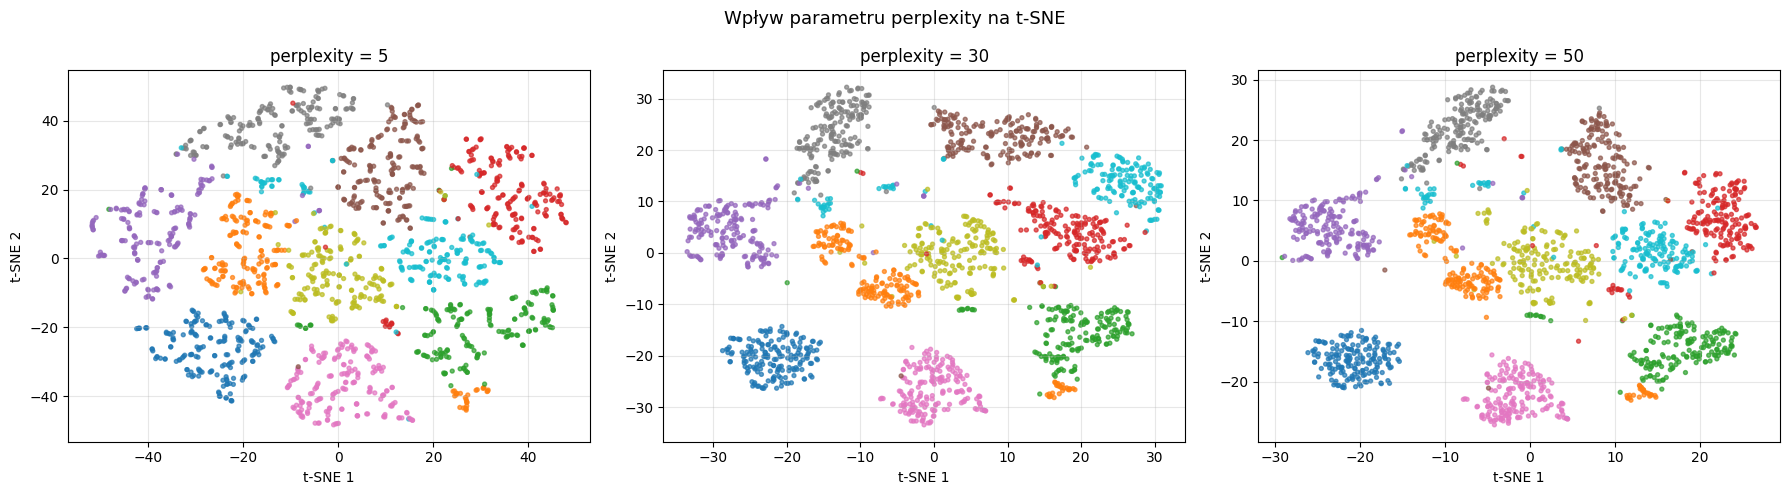

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [5, 30, 50]):
    tsne_exp = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=500)
    X_exp = tsne_exp.fit_transform(X_scaled)
    scatter = ax.scatter(X_exp[:, 0], X_exp[:, 1], c=y, cmap='tab10', s=8, alpha=0.7)
    ax.set_title(f'perplexity = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Wpływ parametru perplexity na t-SNE', fontsize=13)
plt.tight_layout()
plt.show()

## UMAP — Uniform Manifold Approximation and Projection

UMAP to aktualny **state-of-the-art** w redukcji wymiarowości. Jest szybszy niż t-SNE i — co ważniejsze — zachowuje zarówno lokalną jak i globalną strukturę danych.

**Intuicja:** UMAP buduje **graf sąsiedztwa** w oryginalnej przestrzeni (każdy punkt połączony z K najbliższymi sąsiadami), a następnie stara się odtworzyć ten graf w 2D, minimalizując różnicę między strukturami grafów.

Matematycznie jest ugruntowany w **topologicznej analizie danych** i **geometrii Riemannowskiej** — brzmi groźnie, ale praktycznie: UMAP jest lepszy od t-SNE pod każdym względem poza jednym wyjątkiem (t-SNE czasem daje ładniejsze klastry na bardzo specyficznych danych).

**Kluczowe parametry UMAP:**
- `n_neighbors` — ile sąsiadów bierze pod uwagę. Małe → lokalne struktury. Duże → globalne struktury
- `min_dist` — jak ciasno mogą być spakowane punkty w 2D. Małe → ciasne klastry. Duże → luźniejszy rozkład

> **Wskazówka Big Data:** UMAP, w przeciwieństwie do t-SNE, nadaje się do **preprocessingu** przed modelowaniem — zachowuje sensowną globalną strukturę i skaluje się znacznie lepiej. W NVIDIA RAPIDS (cuML) UMAP działa na GPU i radzi sobie z dziesiątkami milionów punktów w sekundy.

Uruchamiam UMAP...


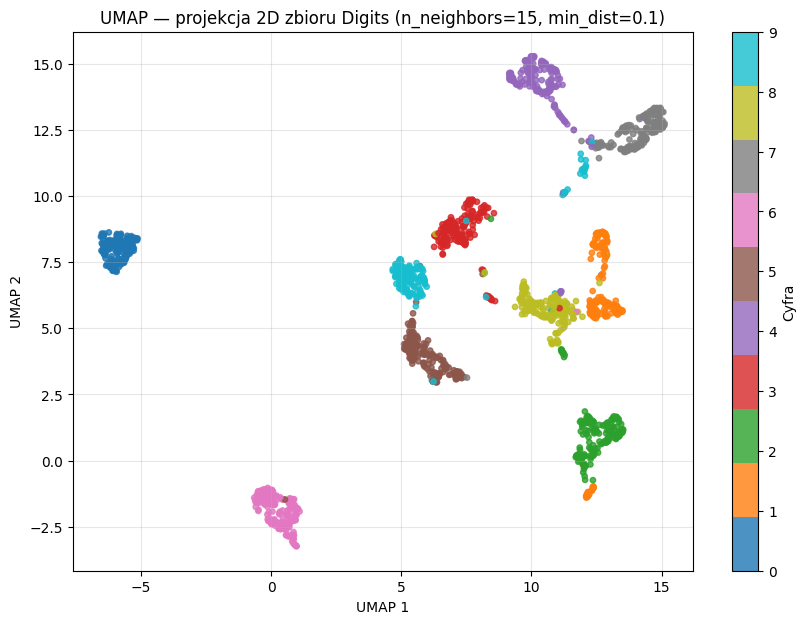

In [69]:
print("Uruchamiam UMAP...")

reducer = umap.UMAP(
    n_neighbors=15,     # balans local vs global: mała wartość = bardziej lokalne
    min_dist=0.1,       # ciasność klastrów w 2D
    n_components=2,
    random_state=42
)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=15, alpha=0.8)
plt.colorbar(scatter, label='Cyfra')
plt.title('UMAP — projekcja 2D zbioru Digits (n_neighbors=15, min_dist=0.1)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.show()

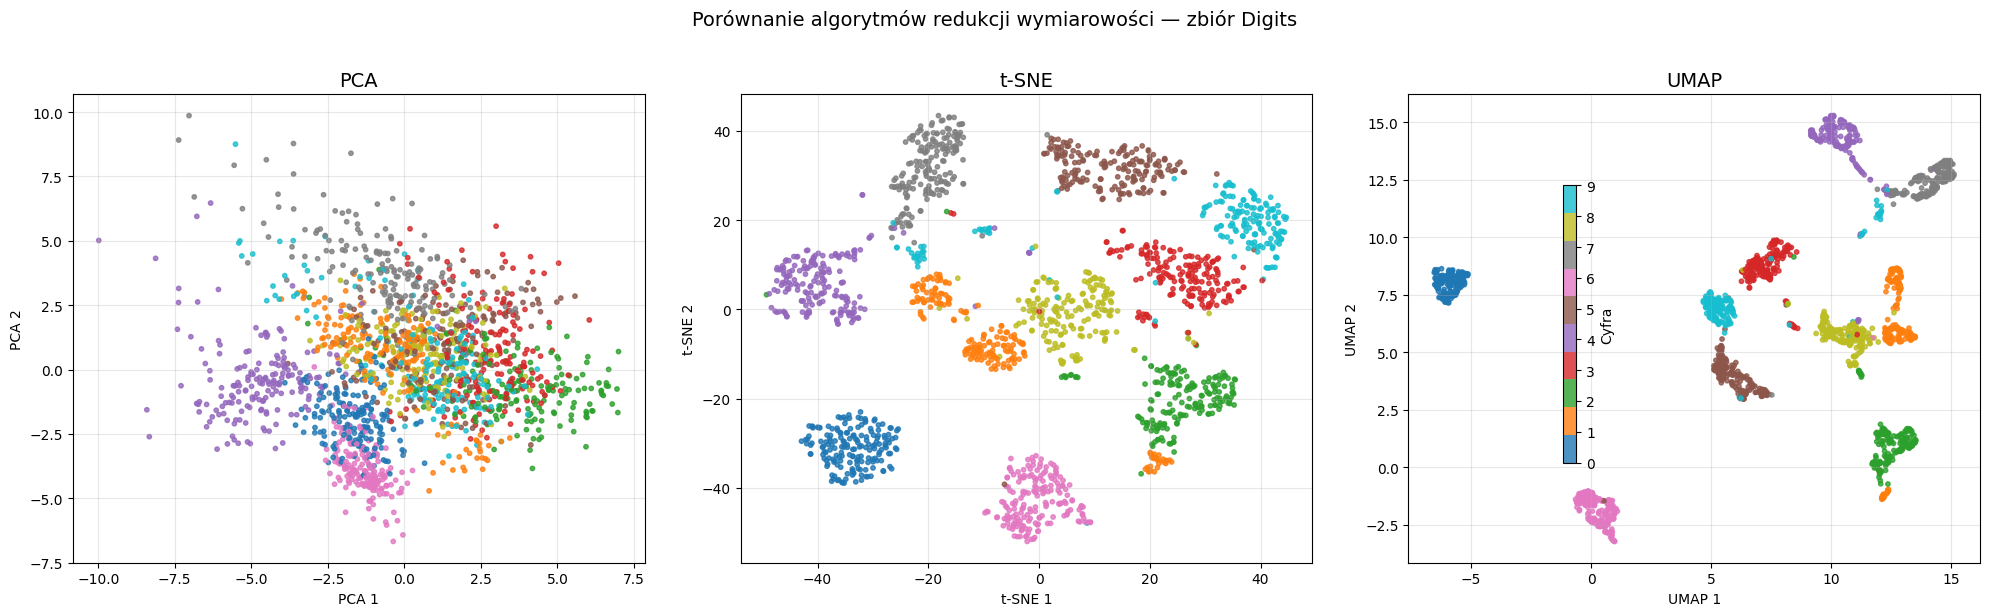

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
datasets = [(X_pca, 'PCA'), (X_tsne, 't-SNE'), (X_umap, 'UMAP')]

for ax, (X_proj, title) in zip(axes, datasets):
    sc = ax.scatter(X_proj[:, 0], X_proj[:, 1], c=y, cmap='tab10', s=10, alpha=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'{title} 1')
    ax.set_ylabel(f'{title} 2')
    ax.grid(True, alpha=0.3)

fig.colorbar(sc, ax=axes, label='Cyfra', shrink=0.6)
plt.suptitle('Porównanie algorytmów redukcji wymiarowości — zbiór Digits', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Podsumowanie: PCA vs t-SNE vs UMAP

| Cecha | PCA | t-SNE | UMAP |
|---|---|---|---|
| **Typ transformacji** | Liniowa | Nieliniowa | Nieliniowa |
| **Deterministyczny** | ✅ Tak | ❌ Stochastyczny | ✅ (z `random_state`) |
| **Szybkość** | ⚡ Bardzo szybki | 🐢 Wolny | 🚀 Szybki |
| **Zachowanie struktury lokalnej** | Słabe | Świetne | Świetne |
| **Zachowanie struktury globalnej** | Dobre | ❌ Słabe | Dobre |
| **Nadaje się do preprocessingu** | ✅ Tak | ❌ Tylko wizualizacja | ✅ Tak |
| **Skalowalność** | Duże dane | ❌ Problem >100k pkt | Duże dane |
| **Interpretowalność osi** | ✅ Explained Variance | ❌ Nie | ❌ Nie |
| **Kluczowy hiperparametr** | `n_components` | `perplexity` | `n_neighbors`, `min_dist` |

**Kiedy co wybierać:**
- **PCA** → preprocessing, kiedy chcesz zmniejszyć wymiarowość przed innym modelem i liczy się szybkość
- **t-SNE** → eksploracja / wizualizacja wysokowymiarowych danych, szukanie klastrów "na oko"
- **UMAP** → zarówno wizualizacja jak i preprocessing; lepsza opcja od t-SNE w 90% przypadków

---
# Część 2: Klasteryzacja

Klasteryzacja to grupowanie danych w **skupiska (klastry)** tak, żeby obiekty w tym samym klastrze były do siebie podobne, a obiekty z różnych klastrów — różne.

Kluczowa różnica od klasyfikacji: **nie wiemy z góry ile klastrów jest w danych** (ani jakie). Algorytm musi to sam odkryć.

Omówimy trzy podejścia:
1. **K-Means** — centroidowe (geometryczne)
2. **DBSCAN** — gęstościowe (topologiczne)
3. **Hierarchical Clustering** — hierarchiczne (drzewiaste)

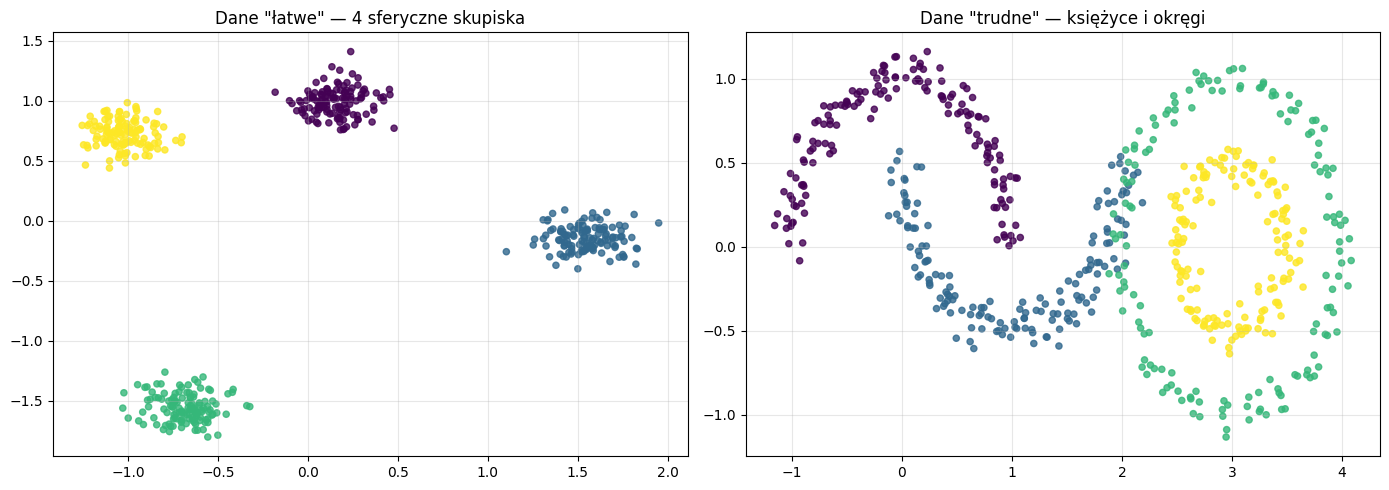

In [71]:
# Tworzymy syntetyczne dane z wyraźnymi skupiskami
X_blobs, y_blobs = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.7,
    random_state=42
)
X_blobs = StandardScaler().fit_transform(X_blobs)

# Tworzymy też "trudniejsze" dane do późniejszego porównania algorytmów
X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=42)
X_circles, y_circles = make_circles(n_samples=300, noise=0.06, factor=0.5, random_state=42)

# Łączymy księżyce i okręgi w jeden trudniejszy dataset
X_hard = np.vstack([X_moons, X_circles + np.array([3, 0])])
y_hard = np.hstack([y_moons, y_circles + 2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('Dane "łatwe" — 4 sferyczne skupiska')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_hard[:, 0], X_hard[:, 1], c=y_hard, cmap='viridis', s=20, alpha=0.8)
axes[1].set_title('Dane "trudne" — księżyce i okręgi')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## K-Means

K-Means to najpopularniejszy algorytm klasteryzacji. Prosty, szybki i działa zaskakująco dobrze na wielu prawdziwych danych.

**Działanie (Algorytm Lloyda):**
1. Losowo zainicjuj K centroidów (punktów środkowych klastrów)
2. Przypisz każdy punkt do najbliższego centroidu (wg odległości Euklidesowej)
3. Przesuń centroid do środka (średniej) wszystkich punktów w jego klastrze
4. Powtarzaj kroki 2–3 aż centroidy przestaną się ruszać

**Co minimalizuje?** tzw. **Inercję** — sumę kwadratów odległości każdego punktu od jego centroidu.

$$\text{Inercja} = \sum_{i=1}^{N} \min_{j \in \{1..K\}} ||x_i - c_j||^2$$

**Ważna inicjalizacja: k-means++**

Standardowy K-Means losuje centroidy zupełnie losowo — może się trafić na zły start i wpaść w minimum lokalne. **k-means++** inicjalizuje centroidy inteligentnie: pierwszy losowo, każdy następny z prawdopodobieństwem proporcjonalnym do kwadratu odległości od już wybranych centroidów. To drastycznie zmniejsza ryzyko słabej konwergencji. W scikit-learn jest to domyślna opcja (`init='k-means++'`).

### Problem: nie wiemy ile klastrów wziąć

K-Means wymaga podania K z góry. Ale skąd wiedzieć? Tu pomaga **Metoda Łokcia (Elbow Method)**.

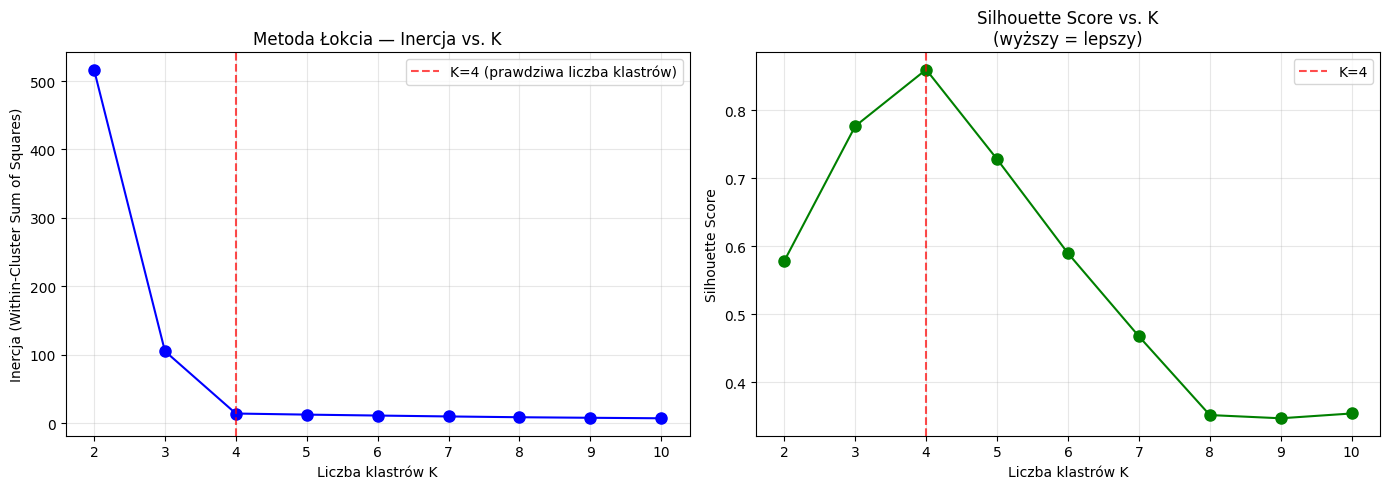

Najlepsze K wg Silhouette Score: 4


In [72]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_blobs)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_blobs, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', markersize=8)
axes[0].axvline(x=4, color='r', linestyle='--', alpha=0.7, label='K=4 (prawdziwa liczba klastrów)')
axes[0].set_title('Metoda Łokcia — Inercja vs. K')
axes[0].set_xlabel('Liczba klastrów K')
axes[0].set_ylabel('Inercja (Within-Cluster Sum of Squares)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'go-', markersize=8)
axes[1].axvline(x=4, color='r', linestyle='--', alpha=0.7, label='K=4')
axes[1].set_title('Silhouette Score vs. K\n(wyższy = lepszy)')
axes[1].set_xlabel('Liczba klastrów K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Najlepsze K wg Silhouette Score: {k_range[np.argmax(silhouette_scores)]}")


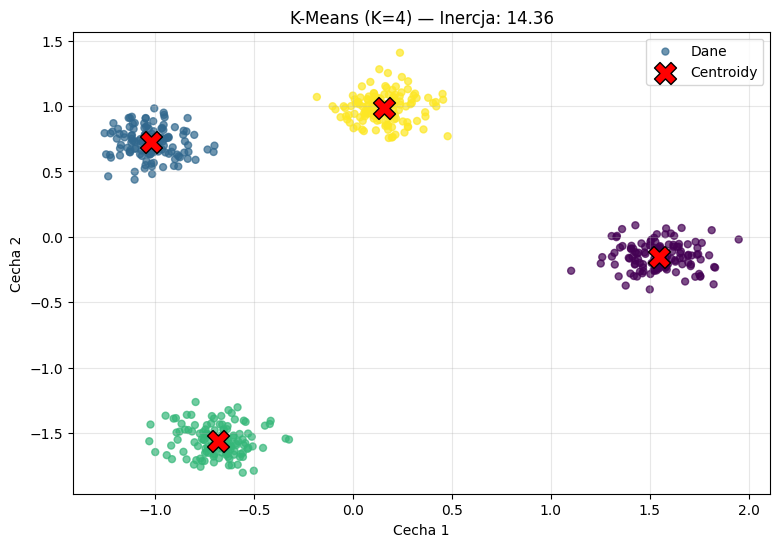

In [73]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_blobs)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(9, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_km, cmap='viridis', s=25, alpha=0.7, label='Dane')
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=250, edgecolors='black', zorder=5, label='Centroidy')
plt.title(f'K-Means (K=4) — Inercja: {kmeans.inertia_:.2f}')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Dlaczego K-Means zawodzi na niektórych kształtach?

K-Means zakłada że klastry są **sferyczne** i mają podobne rozmiary. Gdy klastry mają inny kształt (np. półksiężyce, okręgi, spirale) — K-Means kompletnie sobie nie radzi.

Zobaczmy to na naszych "trudnych" danych.

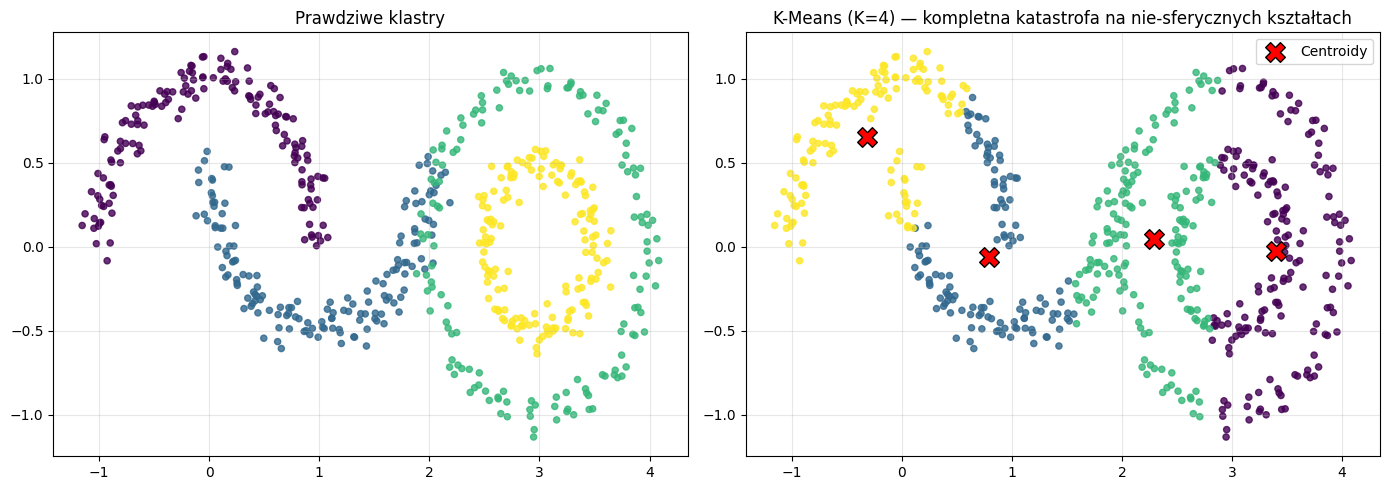

In [74]:
km_hard = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_km_hard = km_hard.fit_predict(X_hard)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_hard[:, 0], X_hard[:, 1], c=y_hard, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('Prawdziwe klastry')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_hard[:, 0], X_hard[:, 1], c=labels_km_hard, cmap='viridis', s=20, alpha=0.8)
centroids_hard = km_hard.cluster_centers_
axes[1].scatter(centroids_hard[:, 0], centroids_hard[:, 1],
                c='red', marker='X', s=200, edgecolors='black', zorder=5, label='Centroidy')
axes[1].set_title('K-Means (K=4) — kompletna katastrofa na nie-sferycznych kształtach')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## DBSCAN — Density-Based Spatial Clustering of Applications with Noise

DBSCAN podchodzi do klasteryzacji zupełnie inaczej. Zamiast szukać centroidów, szuka **gęstych regionów** w przestrzeni danych.

**Kluczowa zaleta:** DBSCAN nie wymaga podania K z góry — sam odkrywa ile klastrów jest w danych. Co więcej, punkty które "nie pasują" do żadnego gęstego regionu są klasyfikowane jako **szum (noise)** z etykietą `-1`.

**Działanie — każdy punkt dostaje jedną z 3 etykiet:**

| Typ punktu | Definicja |
|---|---|
| **Core Point** (rdzeń) | Ma co najmniej `min_samples` sąsiadów w promieniu `eps` |
| **Border Point** (brzeg) | Leży w `eps`-okolicy Core Pointa, ale sam nie spełnia warunku min_samples |
| **Noise Point** (szum) | Nie jest ani Core ani Border — leży w rzadkim obszarze |

**Parametry:**
- `eps` (ε) — promień "sąsiedztwa" każdego punktu. Za mały → wszystko szum. Za duży → wszystko jeden klaster.
- `min_samples` — ile punktów musi być w promieniu ε, żeby punkt był "core". Zazwyczaj `2 * n_features` to dobry punkt startowy.

> **Wskazówka Big Data:** DBSCAN jest jednym z głównych algorytmów w **cybersecurity i fraud detection**. Normalne transakcje tworzą gęste klastry, a podejrzane transakcje — to właśnie punkty szumu (-1). Zamiast pytać "do której grupy to należy?", pytamy "czy to w ogóle jest normalne?".

Odkryte klastry: 3
Punkty szumu (noise):  0 (0.0%)


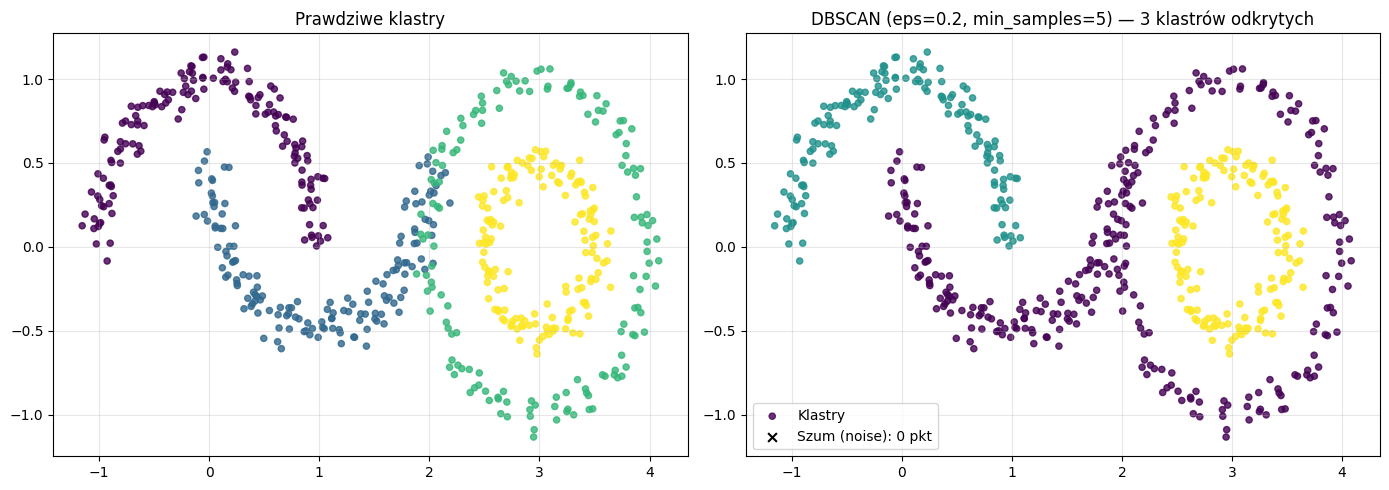

In [75]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X_hard)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

print(f"Odkryte klastry: {n_clusters}")
print(f"Punkty szumu (noise):  {n_noise} ({n_noise/len(labels_db)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_hard[:, 0], X_hard[:, 1], c=y_hard, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('Prawdziwe klastry')
axes[0].grid(True, alpha=0.3)

# Separujemy szum od normalnych punktów
noise_mask = labels_db == -1
cluster_mask = ~noise_mask

axes[1].scatter(X_hard[cluster_mask, 0], X_hard[cluster_mask, 1],
                c=labels_db[cluster_mask], cmap='viridis', s=20, alpha=0.8, label='Klastry')
axes[1].scatter(X_hard[noise_mask, 0], X_hard[noise_mask, 1],
                c='black', marker='x', s=40, label=f'Szum (noise): {n_noise} pkt', zorder=5)
axes[1].set_title(f'DBSCAN (eps=0.2, min_samples=5) — {n_clusters} klastrów odkrytych')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

DBSCAN perfekcyjnie poradził sobie z kształtami gdzie K-Means zawodziło. Zidentyfikował księżyce i okręgi jako osobne klastry, i poprawnie oznaczył punkty odstające jako szum.

### Dobór eps — pomocna wskazówka

Dobry `eps` to taki, w którym "kolano" wykresu odległości do K-tego najbliższego sąsiada zaczyna gwałtownie rosnąć. Sprawdźmy to na naszych danych.

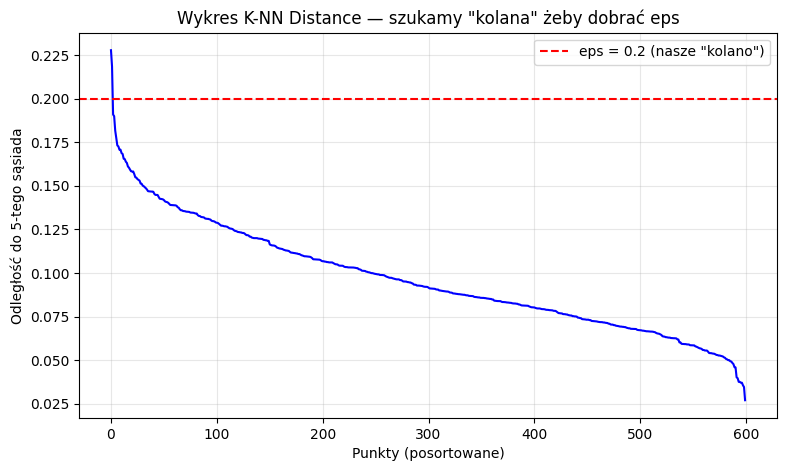

In [76]:
from sklearn.neighbors import NearestNeighbors

# Szukamy k=min_samples najbliższych sąsiadów dla każdego punktu
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_hard)
distances, _ = nn.kneighbors(X_hard)

# Sortujemy odległości do 5-tego sąsiada malejąco
distances_sorted = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(9, 5))
plt.plot(distances_sorted, 'b-')
plt.axhline(y=0.2, color='r', linestyle='--', label='eps = 0.2 (nasze "kolano")')
plt.title('Wykres K-NN Distance — szukamy "kolana" żeby dobrać eps')
plt.xlabel('Punkty (posortowane)')
plt.ylabel('Odległość do 5-tego sąsiada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Hierarchical Clustering (Klasteryzacja Hierarchiczna)

Oba poprzednie algorytmy dają **płaski** podział — każdy punkt dostaje jedną etykietę. Klasteryzacja hierarchiczna robi coś innego: buduje **drzewo klastrów** (dendrogram).

**Podejście Aglomeracyjne (bottom-up):**
1. Na starcie każdy punkt to osobny klaster (N klastrów)
2. Znajdź dwa najbliższe klastry i połącz je w jeden
3. Powtarzaj aż zostanie jeden gigantyczny klaster

Wynikiem jest **dendrogram** — drzewo pokazujące całą historię łączeń. Możemy wyciąć drzewo na dowolnej wysokości i otrzymać żądaną liczbę klastrów.

**Metody łączenia klastrów (linkage):**

| Metoda | Jak liczy odległość między klastrami |
|---|---|
| **Ward** | Minimalizuje wzrost wariancji wewnątrz klastra — najczęściej używana |
| **Complete (max)** | Odległość = max odległość między punktami z obu klastrów |
| **Average** | Odległość = średnia odległość między wszystkimi parami |
| **Single (min)** | Odległość = min odległość — podatna na "chaining effect" |

> **Wskazówka Big Data:** Klasteryzacja hierarchiczna wymaga obliczenia macierzy odległości parami — dla N punktów to O(N²) operacji. Dla małych danych (do ~10k punktów) jest świetna. Na milionach punktów — za wolna. Na dużą skalę używa się aproksymacji lub GPU (RAPIDS cuML).

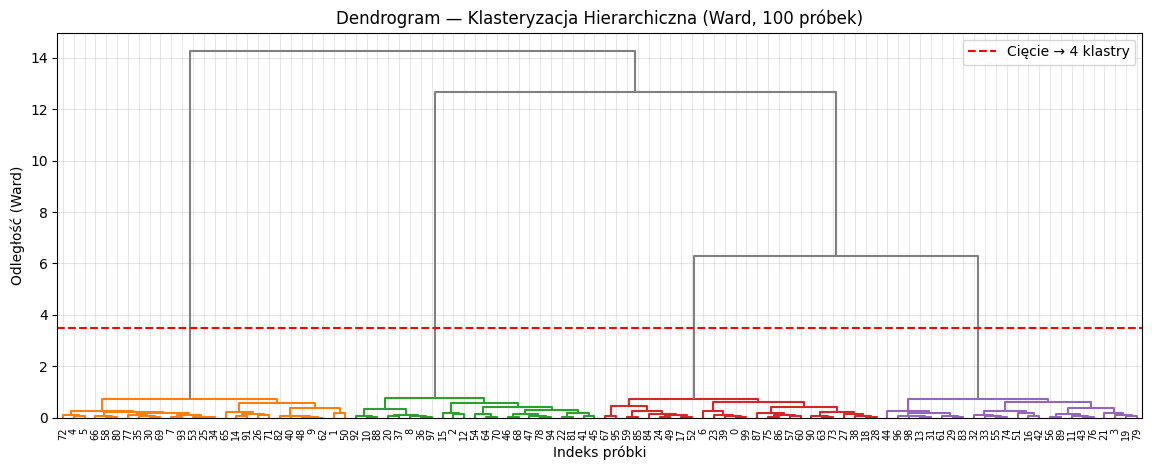

In [77]:
# Scipy linkage działa na surowych danych (nie na obiekcie AgglomerativeClustering)
Z = linkage(X_blobs[:100], method='ward')  # bierzemy 100 próbek żeby dendrogram był czytelny

plt.figure(figsize=(14, 5))
dendrogram(Z,
           leaf_rotation=90,
           leaf_font_size=7,
           color_threshold=3.5,
           above_threshold_color='gray')
plt.axhline(y=3.5, color='r', linestyle='--', label='Cięcie → 4 klastry')
plt.title('Dendrogram — Klasteryzacja Hierarchiczna (Ward, 100 próbek)')
plt.xlabel('Indeks próbki')
plt.ylabel('Odległość (Ward)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

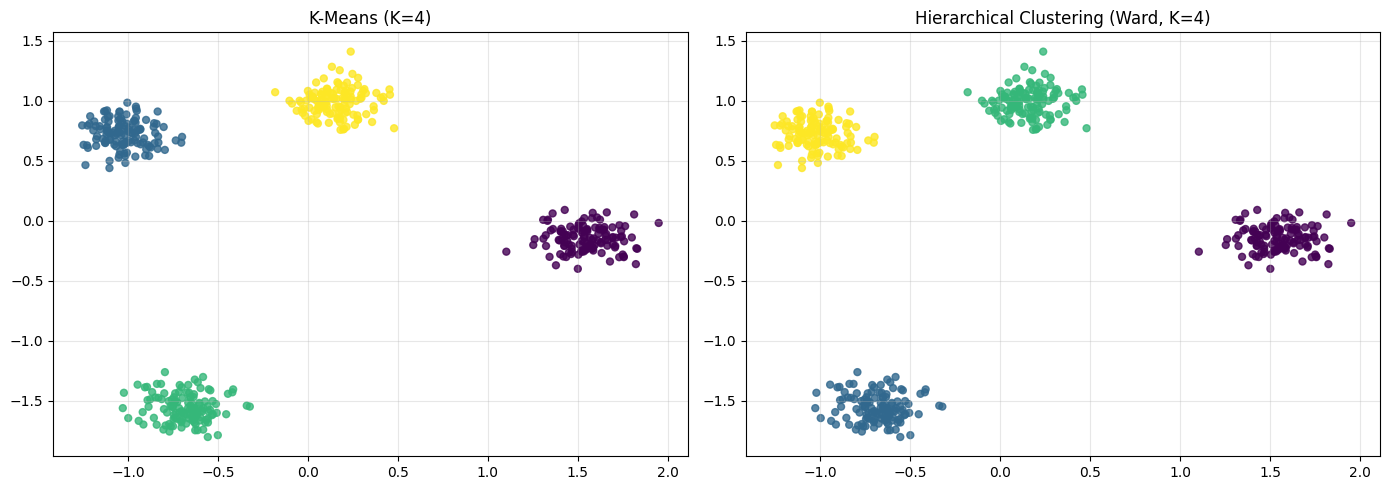

In [78]:
labels_km = kmeans.fit_predict(X_blobs)
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg.fit_predict(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_km, cmap='viridis', s=25, alpha=0.8)
axes[0].set_title('K-Means (K=4)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_agg, cmap='viridis', s=25, alpha=0.8)
axes[1].set_title('Hierarchical Clustering (Ward, K=4)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Porównanie algorytmów klasteryzacji

| Cecha | K-Means | DBSCAN | Hierarchical |
|---|---|---|---|
| **Liczba klastrów** | Trzeba podać z góry (K) | Odkrywa sam | Trzeba podać LUB wybrać z dendrogramu |
| **Kształt klastrów** | Tylko sferyczne | Dowolne kształty | Zależy od linkage |
| **Outliersy** | Wchłania je do klastrów | Oznacza jako szum (-1) | Wchłania je do klastrów |
| **Skalowalność** | ⚡ Bardzo dobra | Dobra | ❌ Słaba (O(N²)) |
| **Parametry** | `n_clusters`, `init` | `eps`, `min_samples` | `n_clusters`, `linkage` |
| **Kiedy używać** | Dużo danych, sferyczne skupiska | Nieznana liczba klastrów, szum | Mało danych, chcesz zobaczyć hierarchię |

---
# Część 3: Metryki Ewaluacji Klasteryzacji

Jak sprawdzić czy nasz algorytm dobrze pogrupował dane? W uczeniu nadzorowanym mamy etykiety i liczymy accuracy / F1. W nienadzorowanym nie mamy etykiet (taki jest cały sens) — musimy użyć metryk opartych na **geometrii klastrów**.

Trzy najważniejsze metryki:


### 1. Silhouette Score

Dla każdego punktu liczymy:
- **a** — średnia odległość do pozostałych punktów w tym samym klastrze (jak bardzo punkt "pasuje" do swojego klastra)
- **b** — średnia odległość do punktów w najbliższym obcym klastrze (jak daleko jest do sąsiedniego klastra)

$$s = \frac{b - a}{\max(a, b)}$$

Wynik w zakresie **[-1, 1]**:
- Bliski **1** → punkt idealnie pasuje do swojego klastra i jest daleko od innych ✅
- Bliski **0** → punkt leży na granicy dwóch klastrów
- Ujemny → punkt jest prawdopodobnie w złym klastrze ❌

### 2. Davies-Bouldin Index

Mierzy stosunek "rozproszenia wewnątrz klastra" do "odległości między klastrami". Im **niższy**, tym lepiej.

### 3. Calinski-Harabasz Index (Variance Ratio Criterion)

Stosunek wariancji między-klastrowej do wariancji wewnątrz-klastrowej. Im **wyższy**, tym lepiej.
"""

In [79]:
results = {}
algorithms = {
    'K-Means (K=4)': labels_km,
    'DBSCAN': labels_db[:500],          # DBSCAN był na X_hard, bierzemy X_blobs do porównania
    'Hierarchical (Ward, K=4)': labels_agg,
}

# Dla sprawiedliwego porównania uruchamiamy DBSCAN też na X_blobs
dbscan_blobs = DBSCAN(eps=0.3, min_samples=5)
labels_db_blobs = dbscan_blobs.fit_predict(X_blobs)
n_clusters_db_blobs = len(set(labels_db_blobs)) - (1 if -1 in labels_db_blobs else 0)

algorithms = {
    'K-Means (K=4)': labels_km,
    f'DBSCAN ({n_clusters_db_blobs} klastrów)': labels_db_blobs,
    'Hierarchical (Ward, K=4)': labels_agg,
}

print(f"{'Algorytm':<30} {'Silhouette ↑':>14} {'Davies-Bouldin ↓':>18} {'Calinski-Harabasz ↑':>22}")
print("-" * 86)

for name, labels in algorithms.items():
    # DBSCAN może oznaczyć punkty jako szum (-1) — wykluczamy je z ewaluacji
    valid = labels != -1
    if valid.sum() < 2 or len(set(labels[valid])) < 2:
        print(f"{name:<30} {'N/A — za mało klastrów':>54}")
        continue

    sil  = silhouette_score(X_blobs[valid], labels[valid])
    db   = davies_bouldin_score(X_blobs[valid], labels[valid])
    ch   = calinski_harabasz_score(X_blobs[valid], labels[valid])

    print(f"{name:<30} {sil:>14.4f} {db:>18.4f} {ch:>22.1f}")

Algorytm                         Silhouette ↑   Davies-Bouldin ↓    Calinski-Harabasz ↑
--------------------------------------------------------------------------------------
K-Means (K=4)                          0.8598             0.1962                11347.2
DBSCAN (4 klastrów)                    0.8598             0.1962                11347.2
Hierarchical (Ward, K=4)               0.8598             0.1962                11347.2


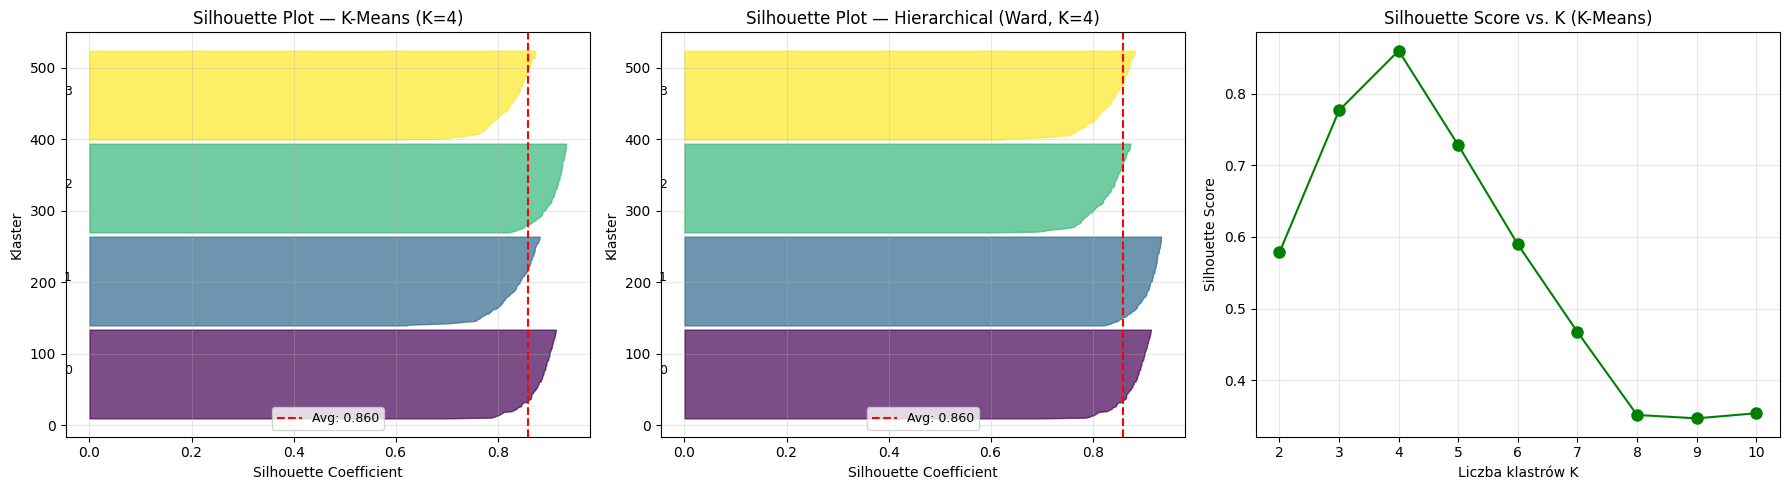

In [80]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
all_labels = [labels_km, labels_agg]
all_names = ['K-Means (K=4)', 'Hierarchical (Ward, K=4)']

for ax, labels, name in zip(axes[:2], all_labels, all_names):
    silhouette_vals = silhouette_samples(X_blobs, labels)
    y_lower = 10

    for cluster_id in sorted(np.unique(labels)):
        cluster_sil = np.sort(silhouette_vals[labels == cluster_id])
        size = len(cluster_sil)
        y_upper = y_lower + size
        color = cm.viridis(cluster_id / max(np.unique(labels)))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7, color=color)
        ax.text(-0.05, y_lower + size / 2, str(cluster_id), fontsize=9)
        y_lower = y_upper + 5

    avg_score = silhouette_score(X_blobs, labels)
    ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Avg: {avg_score:.3f}')
    ax.set_title(f'Silhouette Plot — {name}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Klaster')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Porównanie Silhouette Score
k_values = range(2, 11)
sil_scores = [silhouette_score(X_blobs, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_blobs))
              for k in k_values]
axes[2].plot(k_values, sil_scores, 'go-', markersize=8)
axes[2].set_title('Silhouette Score vs. K (K-Means)')
axes[2].set_xlabel('Liczba klastrów K')
axes[2].set_ylabel('Silhouette Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Część 4: Reguły Asocjacyjne — Analiza Koszyka Zakupowego

Trzecia kategoria uczenia nienadzorowanego działa zupełnie inaczej od powyższych. Zamiast grupować punkty w przestrzeni, szukamy **reguł współwystępowania** w transakcjach.

Klasyczny przykład: badania supermarketów w USA wykazały, że klienci kupujący pieluchy często kupują też piwo 🍺👶. Brzmi absurdalnie, ale ma sens: młodzi ojcowie robią zakupy wieczorem, kupują pieluchy i przy okazji nagradzają się piwkiem.

Ten typ analizy nazywamy **Market Basket Analysis** i jest podstawą systemów rekomendacji (Amazon: "Klienci, którzy kupili X, kupili też Y").

## Algorytm Apriori

Naiwne podejście: sprawdź wszystkie możliwe kombinacje produktów. Przy 1000 produktach → 2¹⁰⁰⁰ kombinacji. Niemożliwe.

Apriori używa sprytnej zasady zwanej **Downward Closure Property (Zasada Apriori)**:

> Jeśli zbiór produktów {A, B, C} jest **rzadki** (rzadko kupowany razem), to każdy nadzbiór {A, B, C, D} też musi być rzadki.

Pozwala to przycinać przestrzeń poszukiwań — jeśli {pieluchy, kawior} rzadko kupowane razem, to nie ma sensu sprawdzać {pieluchy, kawior, foie gras}.

## Metryki reguł asocjacyjnych

Dla reguły {A} → {B}:

| Metryka | Wzór | Interpretacja |
|---|---|---|
| **Support** | P(A ∩ B) | Jak często A i B kupowane razem w ogóle? (popularność reguły) |
| **Confidence** | P(B\|A) = P(A ∩ B) / P(A) | Jeśli klient kupił A, jakie P że kupi też B? |
| **Lift** | P(A ∩ B) / (P(A) · P(B)) | Czy A i B kupowane razem częściej niż losowo? >1 = pozytywna korelacja |
| **Leverage** | P(A ∩ B) - P(A) · P(B) | Absolutna różnica vs. niezależność. 0 = brak związku |

**Lift** jest najważniejszy: Lift = 1 to brak związku. Lift = 3 oznacza że A i B są kupowane razem 3x częściej niż gdyby były niezależne.

In [81]:
# Symulujemy koszyki zakupowe sklepu spożywczego
np.random.seed(42)

dataset = [
    ['mleko', 'chleb', 'masło', 'jajka'],
    ['mleko', 'chleb', 'masło'],
    ['mleko', 'chleb', 'jajka', 'ser'],
    ['chleb', 'masło', 'jajka'],
    ['mleko', 'masło', 'ser', 'jogurt'],
    ['chleb', 'masło', 'jogurt'],
    ['mleko', 'chleb', 'masło', 'jogurt'],
    ['mleko', 'ser', 'jogurt'],
    ['chleb', 'jajka', 'masło', 'ser'],
    ['mleko', 'chleb', 'masło', 'ser', 'jogurt'],
    ['mleko', 'jajka'],
    ['chleb', 'masło', 'jajka', 'jogurt'],
    ['mleko', 'chleb', 'ser'],
    ['masło', 'jajka', 'ser', 'jogurt'],
    ['mleko', 'chleb', 'masło', 'jajka', 'ser', 'jogurt'],
    ['mleko', 'chleb'],
    ['jajka', 'ser', 'jogurt'],
    ['mleko', 'masło', 'jajka'],
    ['chleb', 'ser', 'jogurt'],
    ['mleko', 'chleb', 'masło', 'jogurt'],
]

print(f"Liczba transakcji: {len(dataset)}")
print(f"\nPrzykładowe koszyki:")
for i, basket in enumerate(dataset[:5], 1):
    print(f"  Koszyk {i}: {basket}")

Liczba transakcji: 20

Przykładowe koszyki:
  Koszyk 1: ['mleko', 'chleb', 'masło', 'jajka']
  Koszyk 2: ['mleko', 'chleb', 'masło']
  Koszyk 3: ['mleko', 'chleb', 'jajka', 'ser']
  Koszyk 4: ['chleb', 'masło', 'jajka']
  Koszyk 5: ['mleko', 'masło', 'ser', 'jogurt']


In [82]:
te = TransactionEncoder()
te_array = te.fit(dataset).transform(dataset)
df_transactions = pd.DataFrame(te_array, columns=te.columns_)

print("One-Hot Encoded transakcje (True = produkt w koszyku):")
df_transactions.head(8)


# =============================================================================
# [CODE] CELL 40 — Częste zbiory przedmiotów (Apriori)
# =============================================================================

# min_support = 0.4 → itemset musi pojawić się w co najmniej 40% transakcji
frequent_itemsets = apriori(df_transactions, min_support=0.4, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets_sorted = frequent_itemsets.sort_values('support', ascending=False)

print(f"Znalezione częste itemsety (support ≥ 40%): {len(frequent_itemsets)}\n")
print(frequent_itemsets_sorted.to_string(index=False))

One-Hot Encoded transakcje (True = produkt w koszyku):
Znalezione częste itemsety (support ≥ 40%): 10

 support                   itemsets  length
    0.70         frozenset({chleb})       1
    0.65         frozenset({masło})       1
    0.65         frozenset({mleko})       1
    0.55        frozenset({jogurt})       1
    0.50         frozenset({jajka})       1
    0.50           frozenset({ser})       1
    0.50  frozenset({masło, chleb})       2
    0.45  frozenset({mleko, chleb})       2
    0.40 frozenset({jogurt, masło})       2
    0.40  frozenset({mleko, masło})       2


In [83]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.7,      # reguła musi mieć Confidence ≥ 70%
    num_itemsets=len(frequent_itemsets)
)

# Sortujemy po Lift — najciekawsze reguły najpierw
rules_sorted = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage']]\
    .sort_values('lift', ascending=False)

print(f"Wygenerowane reguły (confidence ≥ 70%): {len(rules)}\n")
print(rules_sorted.to_string(index=False))

Wygenerowane reguły (confidence ≥ 70%): 3

        antecedents        consequents  support  confidence     lift  leverage
frozenset({jogurt}) frozenset({masło})      0.4    0.727273 1.118881    0.0425
 frozenset({masło}) frozenset({chleb})      0.5    0.769231 1.098901    0.0450
 frozenset({chleb}) frozenset({masło})      0.5    0.714286 1.098901    0.0450


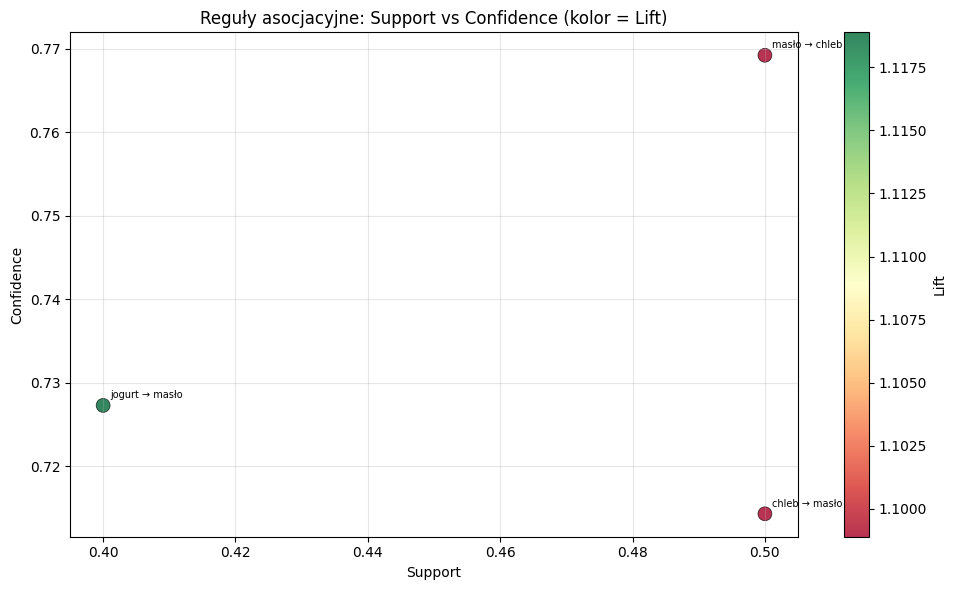

In [84]:
if len(rules) > 0:
    plt.figure(figsize=(10, 6))
    sc = plt.scatter(
        rules['support'],
        rules['confidence'],
        c=rules['lift'],
        cmap='RdYlGn',
        s=100,
        alpha=0.8,
        edgecolors='black',
        linewidth=0.5
    )
    plt.colorbar(sc, label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Reguły asocjacyjne: Support vs Confidence (kolor = Lift)')
    plt.grid(True, alpha=0.3)

    # Annotate the top rules by lift
    for _, row in rules_sorted.head(5).iterrows():
        ant = ', '.join(list(row['antecedents']))
        con = ', '.join(list(row['consequents']))
        plt.annotate(f"{ant} → {con}",
                     xy=(row['support'], row['confidence']),
                     xytext=(5, 5), textcoords='offset points', fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("Brak reguł spełniających próg — spróbuj obniżyć min_threshold lub min_support")

## Jak interpretować wyniki?

Reguła `{chleb, masło} → {mleko}` z:
- **Support = 0.40** → te trzy produkty kupowane razem w 40% transakcji
- **Confidence = 0.80** → jeśli ktoś kupuje chleb i masło, w 80% przypadków kupuje też mleko
- **Lift = 1.33** → te produkty kupowane razem 33% częściej niż gdyby były niezależne

Lift > 1 to zielone światło: **jest prawdziwa zależność**. To właśnie taka reguła powinna się znaleźć przy kasie jako oferta specjalna, albo produkty powinny stać blisko siebie na półce.

---
# Podsumowanie

Omówiliśmy trzy filary uczenia nienadzorowanego:

### 1. Redukcja Wymiarowości
| | PCA | t-SNE | UMAP |
|---|---|---|---|
| Typ | Liniowa | Nieliniowa | Nieliniowa |
| Główne zastosowanie | Preprocessing | Wizualizacja | Wizualizacja + Preprocessing |
| Szybkość | ⚡⚡⚡ | ⚡ | ⚡⚡ |
| Zachowuje strukturę globalną | ✅ | ❌ | ✅ |

### 2. Klasteryzacja
| | K-Means | DBSCAN | Hierarchical |
|---|---|---|---|
| K z góry? | ✅ Wymagany | ❌ Odkrywa sam | ✅ Lub z dendrogramu |
| Kształty | Sferyczne | Dowolne | Zależy od linkage |
| Noise | Wchłania | Oznacza jako -1 | Wchłania |
| Skala | Duże dane | Średnie dane | Małe dane |

### 3. Reguły Asocjacyjne
- **Support** — jak popularna jest reguła
- **Confidence** — jak niezawodna jest reguła
- **Lift > 1** — jest prawdziwa zależność (a nie przypadek)

> **Wskazówka Big Data:** W produkcji reguły asocjacyjne generowane są ciągłe ze strumieni transakcji (np. Apache Kafka + Spark MLlib). Zamiast Apriori używa się często jego szybszej wersji — **FP-Growth** (Frequent Pattern Growth), który nie generuje kandydatów a używa specjalnej struktury drzewa FP-Tree. Jest od Apriori wielokrotnie szybszy na dużych zbiorach danych.